In [ ]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
np.random.seed(42)
random.seed(42)

In [ ]:
base_dir = "logo_dataset"
real_dir = os.path.join(base_dir, "real")
fake_dir = os.path.join(base_dir, "fake")

os.makedirs(real_dir, exist_ok=True)
os.makedirs(fake_dir, exist_ok=True)

In [ ]:
IMG_SIZE = 128
NUM_IMAGES = 200

In [ ]:
def create_real_logo(path):
    img = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8) * 255
    color = (0, 0, 0)
    cv2.circle(img, (64, 64), 40, color, -1)
    cv2.putText(img, "LOGO", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
    cv2.imwrite(path, img)

In [ ]:
def create_fake_logo(path):
    img = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8) * 255
    color = (random.randint(0,255), random.randint(0,255), random.randint(0,255))
    cv2.ellipse(img, (64, 64), (40,30), random.randint(0,180),
                0, 360, color, -1)

    noise = np.random.randint(0,50,(IMG_SIZE,IMG_SIZE,3), dtype=np.uint8)
    img = cv2.add(img, noise)
    img = cv2.GaussianBlur(img,(5,5),0)

    cv2.imwrite(path, img)

In [ ]:
for i in range(NUM_IMAGES):
    create_real_logo(os.path.join(real_dir, f"real_{i}.png"))
    create_fake_logo(os.path.join(fake_dir, f"fake_{i}.png"))

print("Dataset Generated Successfully!")

Dataset Generated Successfully!


In [ ]:
data = []
labels = []

for label, folder in enumerate([real_dir, fake_dir]):
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        data.append(img)
        labels.append(label)

data = np.array(data) / 255.0
labels = to_categorical(labels, 2)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=16
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 547ms/step - accuracy: 0.8333 - loss: 0.2528 - val_accuracy: 1.0000 - val_loss: 6.5565e-08
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 522ms/step - accuracy: 1.0000 - loss: 4.6542e-04 - val_accuracy: 1.0000 - val_loss: 1.1325e-07
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 503ms/step - accuracy: 1.0000 - loss: 2.4008e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 552ms/step - accuracy: 1.0000 - loss: 3.0205e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 487ms/step - accuracy: 1.0000 - loss: 9.9743e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 579ms/step - accuracy: 1.0000 - loss: 2.4805e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 548ms/step - accuracy: 1.0000 - loss: 7.7648e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 548

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# ---------- CONFUSION MATRIX ----------
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real Logo", "Fake Logo"]))


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Accuracy: 100.00%
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step

Confusion Matrix:
[[44  0]
 [ 0 36]]

Classification Report:
              precision    recall  f1-score   support

   Real Logo       1.00      1.00      1.00        44
   Fake Logo       1.00      1.00      1.00        36

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


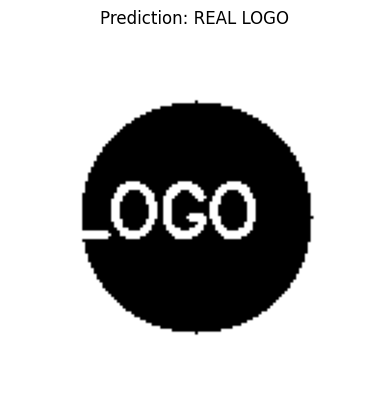

In [ ]:
import matplotlib.pyplot as plt
test_img = X_test[2]
prediction = model.predict(np.expand_dims(test_img, axis=0))
label = np.argmax(prediction)

plt.imshow(test_img)
plt.title("Prediction: " + ("REAL LOGO" if label == 0 else "FAKE LOGO"))
plt.axis("off")
plt.show()